In [1]:
!pip install -q transformers sentencepiece spacy pandas numpy matplotlib seaborn plotly
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 92.8 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import re
import numpy as np
import pandas as pd

import torch
import spacy

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from collections import Counter

from transformers import pipeline
from IPython.display import display, HTML

In [3]:
device = 0 if torch.cuda.is_available() else -1

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [4]:
nlp = spacy.load("en_core_web_sm")

print("spaCy loaded successfully!")

spaCy loaded successfully!


In [5]:
ABSA_MODEL = "yangheng/deberta-v3-base-absa-v1.1"

absa_classifier = pipeline(
    "text-classification",
    model=ABSA_MODEL,
    device=device
)

print("ABSA model loaded successfully!")

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  738MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/372 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/18.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

ABSA model loaded successfully!


In [6]:
review = """
The camera quality is excellent but the battery life is terrible.
"""

aspect = "camera"

result = absa_classifier(
    review,
    text_pair=aspect
)

print(result)

[{'label': 'Positive', 'score': 0.9978146553039551}]


In [7]:
def extract_aspects(review):
    doc = nlp(review)

    aspects = []

    for chunk in doc.noun_chunks:
        phrase = chunk.text.strip().lower()

        # Remove very small / meaningless phrases
        if len(phrase) < 3:
            continue

        # Remove pronouns and generic words
        if phrase in {
            "it", "this", "that", "i", "we", "they",
            "he", "she", "thing", "stuff", "product"
        }:
            continue

        aspects.append(phrase)

    # Also collect important noun/proper noun tokens
    for token in doc:
        if token.pos_ in ["NOUN", "PROPN"]:
            word = token.text.strip().lower()

            if len(word) >= 3:
                aspects.append(word)

    # Remove duplicates
    aspects = list(dict.fromkeys(aspects))

    return aspects

In [8]:
review = """
The camera quality is excellent but the battery life is terrible.
The display is bright and the speakers are good.
"""

aspects = extract_aspects(review)

print("Candidate aspects:")
for aspect in aspects:
    print("-", aspect)

Candidate aspects:
- the camera quality
- the battery life
- the display
- the speakers
- camera
- quality
- battery
- life
- display
- speakers


In [9]:
STOP_ASPECTS = {
    "thing",
    "things",
    "stuff",
    "time",
    "way",
    "lot",
    "one",
    "something",
    "anything",
    "product"
}


def clean_aspects(aspects):
    cleaned = []

    for aspect in aspects:
        aspect = aspect.strip().lower()

        if aspect in STOP_ASPECTS:
            continue

        if len(aspect) < 3:
            continue

        if aspect not in cleaned:
            cleaned.append(aspect)

    return cleaned

In [11]:
def analyze_aspect(review, aspect):
    result = absa_classifier(
        review,
        text_pair=aspect
    )[0]

    return {
        "aspect": aspect,
        "sentiment": result["label"],
        "confidence": round(result["score"], 4)
    }

In [12]:

review = """
The camera quality is excellent but the battery life is terrible.
"""

print(analyze_aspect(review, "camera quality"))
print(analyze_aspect(review, "battery life"))

{'aspect': 'camera quality', 'sentiment': 'Positive', 'confidence': 0.9981}
{'aspect': 'battery life', 'sentiment': 'Negative', 'confidence': 0.9939}


In [13]:
def analyze_review(review):
    
    # Step 1: Extract candidate aspects
    aspects = extract_aspects(review)

    # Step 2: Clean aspects
    aspects = clean_aspects(aspects)

    results = []

    # Step 3: Predict sentiment for every aspect
    for aspect in aspects:
        result = analyze_aspect(review, aspect)
        results.append(result)

    return pd.DataFrame(results)

In [14]:
review = """
The camera quality is excellent but the battery life is terrible.
The display is bright and the speakers sound amazing.
However, the charging speed is slow.
"""

results_df = analyze_review(review)

results_df

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,aspect,sentiment,confidence
0,the camera quality,Positive,0.9969
1,the battery life,Negative,0.9874
2,the display,Positive,0.9965
3,the speakers,Positive,0.9962
4,the charging speed,Negative,0.9904
5,camera,Positive,0.9968
6,quality,Positive,0.9960
7,battery,Negative,0.9737
8,life,Negative,0.9807
9,display,Positive,0.9971


In [15]:
def confidence_category(score):
    if score >= 0.90:
        return "High"
    elif score >= 0.70:
        return "Medium"
    else:
        return "Low"


results_df["confidence_level"] = (
    results_df["confidence"]
    .apply(confidence_category)
)

results_df

,aspect,sentiment,confidence,confidence_level
0,the camera quality,Positive,0.9969,High
1,the battery life,Negative,0.9874,High
2,the display,Positive,0.9965,High
3,the speakers,Positive,0.9962,High
4,the charging speed,Negative,0.9904,High
5,camera,Positive,0.9968,High
6,quality,Positive,0.9960,High
7,battery,Negative,0.9737,High
8,life,Negative,0.9807,High
9,display,Positive,0.9971,High


In [16]:
positive_aspects = results_df[
    results_df["sentiment"].str.lower() == "positive"
]

negative_aspects = results_df[
    results_df["sentiment"].str.lower() == "negative"
]

print("Positive Aspects:")
display(positive_aspects)

print("\nNegative Aspects:")
display(negative_aspects)

Positive Aspects:


,aspect,sentiment,confidence,confidence_level
0,the camera quality,Positive,0.9969,High
2,the display,Positive,0.9965,High
3,the speakers,Positive,0.9962,High
5,camera,Positive,0.9968,High
6,quality,Positive,0.9960,High
9,display,Positive,0.9971,High
10,speakers,Positive,0.9969,High



Negative Aspects:


,aspect,sentiment,confidence,confidence_level
1,the battery life,Negative,0.9874,High
4,the charging speed,Negative,0.9904,High
7,battery,Negative,0.9737,High
8,life,Negative,0.9807,High
11,speed,Negative,0.9874,High


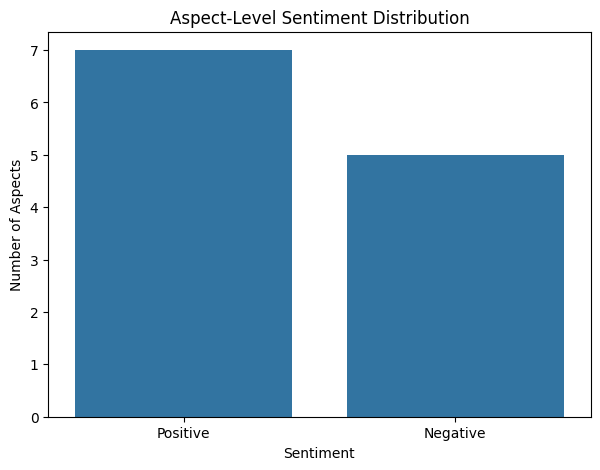

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=results_df,
    x="sentiment"
)

plt.title("Aspect-Level Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Aspects")

plt.show()

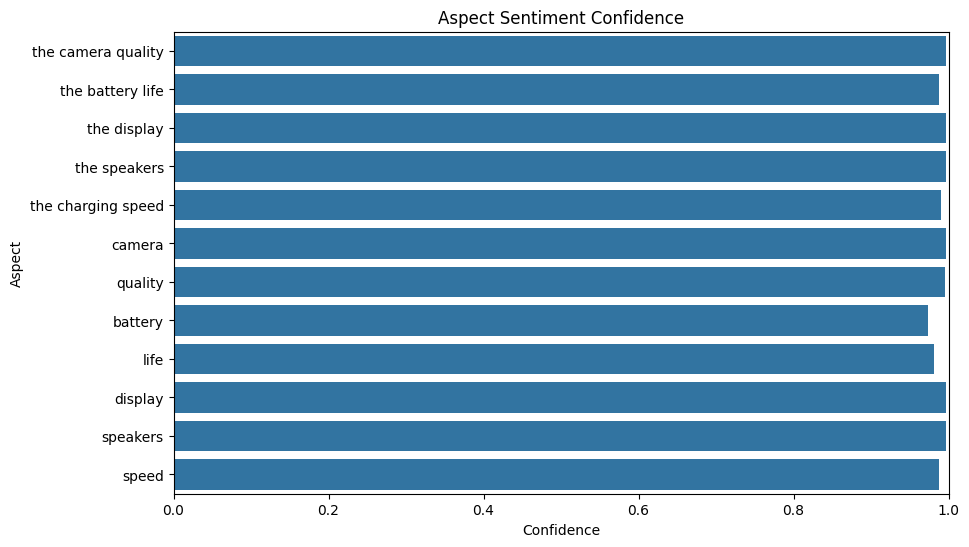

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="confidence",
    y="aspect"
)

plt.title("Aspect Sentiment Confidence")
plt.xlabel("Confidence")
plt.ylabel("Aspect")

plt.xlim(0, 1)

plt.show()

In [20]:
sentiment_counts = (
    results_df
    .groupby(["aspect", "sentiment"])
    .size()
    .reset_index(name="count")
)

fig = px.bar(
    sentiment_counts,
    x="aspect",
    y="count",
    color="sentiment",
    title="Positive and Negative Product Aspects",
    barmode="group"
)

fig.show()

In [21]:
total_aspects = len(results_df)

positive_count = len(positive_aspects)
negative_count = len(negative_aspects)

avg_confidence = results_df["confidence"].mean()

print("========== PRODUCT REVIEW SUMMARY ==========")

print(f"Total Aspects Detected : {total_aspects}")
print(f"Positive Aspects       : {positive_count}")
print(f"Negative Aspects       : {negative_count}")
print(f"Average Confidence     : {avg_confidence:.2%}")

========== PRODUCT REVIEW SUMMARY ==========
Total Aspects Detected : 12
Positive Aspects       : 7
Negative Aspects       : 5
Average Confidence     : 99.13%


In [22]:
def overall_sentiment(df):
    
    if len(df) == 0:
        return "Unknown"

    positive = (
        df["sentiment"]
        .str.lower()
        .eq("positive")
        .sum()
    )

    negative = (
        df["sentiment"]
        .str.lower()
        .eq("negative")
        .sum()
    )

    if positive > negative:
        return "Positive"
    elif negative > positive:
        return "Negative"
    else:
        return "Mixed"


overall = overall_sentiment(results_df)

print("Overall Review Sentiment:", overall)

Overall Review Sentiment: Positive


In [24]:
def show_dashboard(review, results_df):

    positive = results_df[
        results_df["sentiment"].str.lower() == "positive"
    ]

    negative = results_df[
        results_df["sentiment"].str.lower() == "negative"
    ]

    overall = overall_sentiment(results_df)

    avg_conf = results_df["confidence"].mean()

    display(HTML(f"""
    <h1 style="text-align:center;">
        Product Review Intelligence Dashboard
    </h1>

    <hr>

    <h3>Review</h3>
    <p>{review}</p>

    <h3>Overall Sentiment: {overall}</h3>

    <p>
    <b>Total Aspects:</b> {len(results_df)}
    &nbsp;&nbsp;&nbsp;
    <b>Positive:</b> {len(positive)}
    &nbsp;&nbsp;&nbsp;
    <b>Negative:</b> {len(negative)}
    &nbsp;&nbsp;&nbsp;
    <b>Avg Confidence:</b> {avg_conf:.2%}
    </p>
    """))

    print("\nDetected Aspects:")
    display(results_df)

    print("\nPositive Aspects:")
    display(positive)

    print("\nNegative Aspects:")
    display(negative)

    # Sentiment chart
    plt.figure(figsize=(7, 5))

    sns.countplot(
        data=results_df,
        x="sentiment"
    )

    plt.title("Aspect Sentiment Distribution")
    plt.show()

    # Confidence chart
    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=results_df,
        x="confidence",
        y="aspect"
    )

    plt.xlim(0, 1)
    plt.title("Aspect Confidence")
    plt.show()


Detected Aspects:


,aspect,sentiment,confidence
0,the camera quality,Positive,0.9960
1,the display,Positive,0.9966
2,the battery life,Negative,0.9928
3,the speakers,Positive,0.9864
4,camera,Positive,0.9967
5,quality,Positive,0.9959
6,display,Positive,0.9971
7,battery,Negative,0.9920
8,life,Negative,0.9932
9,speakers,Positive,0.9885



Positive Aspects:


,aspect,sentiment,confidence
0,the camera quality,Positive,0.9960
1,the display,Positive,0.9966
3,the speakers,Positive,0.9864
4,camera,Positive,0.9967
5,quality,Positive,0.9959
6,display,Positive,0.9971
9,speakers,Positive,0.9885



Negative Aspects:


,aspect,sentiment,confidence
2,the battery life,Negative,0.9928
7,battery,Negative,0.9920
8,life,Negative,0.9932


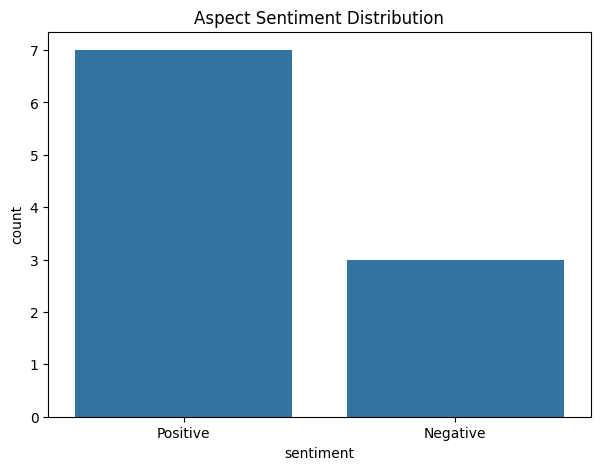

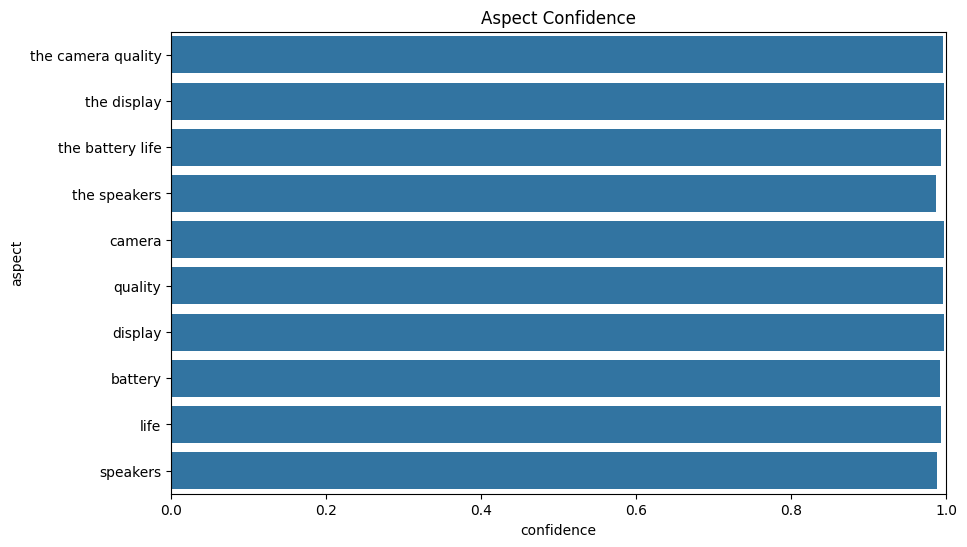

In [25]:
review = """
The camera quality is excellent and the display is beautiful.
The battery life is terrible and charging is very slow.
The speakers are surprisingly good.
"""

results = analyze_review(review)

show_dashboard(review, results)

Enter your product review:
 the camera is excellent but the battery is poor.



Detected Aspects:


,aspect,sentiment,confidence
0,the camera,Positive,0.9977
1,the battery,Negative,0.9931
2,camera,Positive,0.9978
3,battery,Negative,0.9934



Positive Aspects:


,aspect,sentiment,confidence
0,the camera,Positive,0.9977
2,camera,Positive,0.9978



Negative Aspects:


,aspect,sentiment,confidence
1,the battery,Negative,0.9931
3,battery,Negative,0.9934


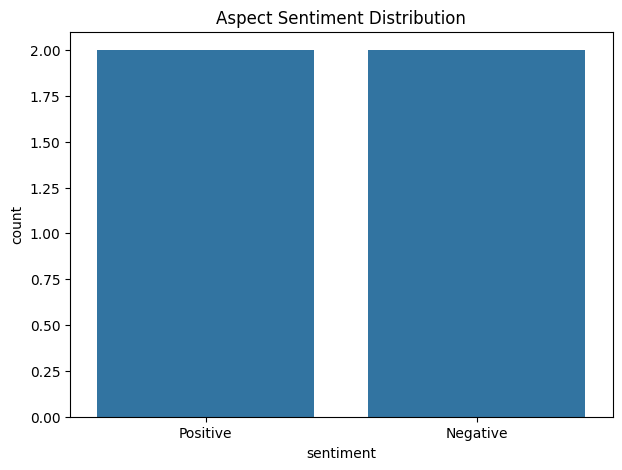

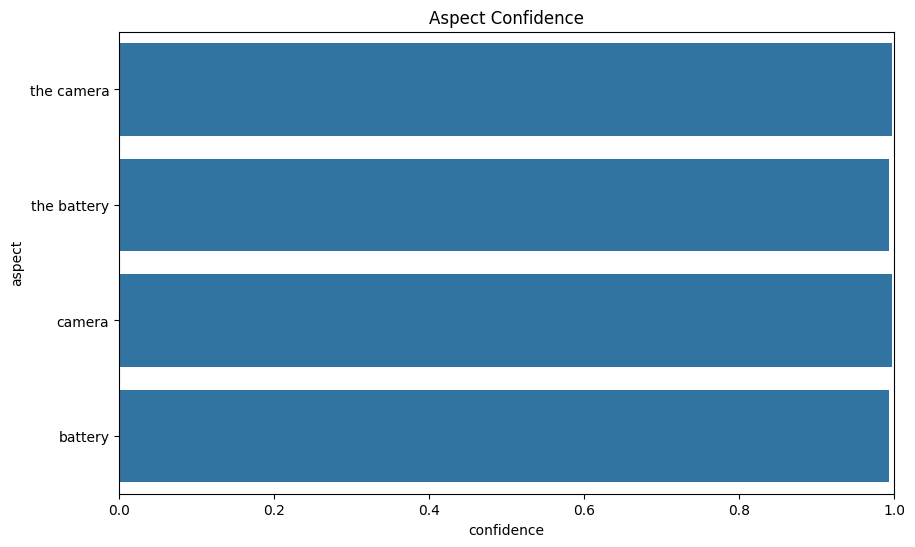

In [26]:
user_review = input("Enter your product review:\n")

results = analyze_review(user_review)

show_dashboard(user_review, results)

In [27]:
reviews = [
    "The camera is excellent but the battery is poor.",
    "Amazing display and great speakers.",
    "The battery life is terrible and charging is slow.",
    "The keyboard is comfortable but the trackpad is disappointing.",
    "Excellent performance and beautiful screen."
]

all_results = []

for review_id, review in enumerate(reviews, start=1):

    df = analyze_review(review)

    if len(df) > 0:
        df["review_id"] = review_id
        df["review"] = review

        all_results.append(df)

all_reviews_df = pd.concat(
    all_results,
    ignore_index=True
)

all_reviews_df

,aspect,sentiment,confidence,review_id,review
0,the camera,Positive,0.9976,1,The camera is excellent but the battery is poor.
1,the battery,Negative,0.9940,1,The camera is excellent but the battery is poor.
2,camera,Positive,0.9976,1,The camera is excellent but the battery is poor.
3,battery,Negative,0.9943,1,The camera is excellent but the battery is poor.
4,amazing display,Positive,0.9919,2,Amazing display and great speakers.
5,great speakers,Positive,0.9935,2,Amazing display and great speakers.
6,display,Positive,0.9979,2,Amazing display and great speakers.
7,speakers,Positive,0.9977,2,Amazing display and great speakers.
8,the battery life,Negative,0.9969,3,The battery life is terrible and charging is s...
9,battery,Negative,0.9964,3,The battery life is terrible and charging is s...


In [28]:
aspect_summary = (
    all_reviews_df
    .groupby(["aspect", "sentiment"])
    .agg(
        mentions=("aspect", "count"),
        avg_confidence=("confidence", "mean")
    )
    .reset_index()
)

aspect_summary

,aspect,sentiment,mentions,avg_confidence
0,amazing display,Positive,1,0.99190
1,battery,Negative,2,0.99535
2,beautiful screen,Positive,1,0.99770
3,camera,Positive,1,0.99760
4,display,Positive,1,0.99790
5,excellent performance,Positive,1,0.99470
6,great speakers,Positive,1,0.99350
7,keyboard,Positive,1,0.99810
8,life,Negative,1,0.99610
9,performance,Positive,1,0.99820


In [29]:
most_positive = (
    all_reviews_df[
        all_reviews_df["sentiment"].str.lower() == "positive"
    ]
    .groupby("aspect")
    .agg(
        mentions=("aspect", "count"),
        avg_confidence=("confidence", "mean")
    )
    .sort_values(
        ["mentions", "avg_confidence"],
        ascending=False
    )
)

display(most_positive.head(10))

,mentions,avg_confidence
aspect,,
screen,1,0.9983
performance,1,0.9982
keyboard,1,0.9981
display,1,0.9979
beautiful screen,1,0.9977
speakers,1,0.9977
camera,1,0.9976
the camera,1,0.9976
the keyboard,1,0.9976


In [30]:
most_negative = (
    all_reviews_df[
        all_reviews_df["sentiment"].str.lower() == "negative"
    ]
    .groupby("aspect")
    .agg(
        mentions=("aspect", "count"),
        avg_confidence=("confidence", "mean")
    )
    .sort_values(
        ["mentions", "avg_confidence"],
        ascending=False
    )
)

display(most_negative.head(10))

,mentions,avg_confidence
aspect,,
battery,2,0.99535
the battery life,1,0.99690
life,1,0.99610
the trackpad,1,0.99580
trackpad,1,0.99530
the battery,1,0.99400


In [31]:
fig = px.bar(
    aspect_summary,
    x="aspect",
    y="mentions",
    color="sentiment",
    title="Product Aspect Intelligence",
    barmode="group"
)

fig.update_layout(
    xaxis_title="Product Aspect",
    yaxis_title="Number of Mentions"
)

fig.show()